<a href="https://www.kaggle.com/code/aamir28/global-homicide-rates-by-country-sex-and-age?scriptVersionId=345949508" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 45%, #5d7488 78%, #8fa2b0 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">201 Countries &middot; 1990-2023 &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 34px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Global Homicide Rates by Country, Sex, and Age</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at WHO-style homicide rate data across three decades &mdash; walking from raw data through coverage gaps, demographic patterns, regional comparison, and country-level trends over time.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">22,092</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">34</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Years</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">3.15&times;</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Male:Female</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (slate ink -> pale mist)
INK, SLATE, STEEL, MIST, RUST = '#1c2733', '#334759', '#5d7488', '#8fa2b0', '#a8562f'

df = pd.read_csv('/kaggle/input/datasets/lucalullo/global-homicide-rates-by-country/tassi-di-omicidi-globali-per-paese.csv')
df.shape

(22092, 6)

<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and understand this dataset's shape before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22092 entries, 0 to 22091
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso_code       22092 non-null  object 
 1   country        22092 non-null  object 
 2   year           22092 non-null  int64  
 3   sex            22092 non-null  object 
 4   age_group      22092 non-null  object 
 5   homicide_rate  22092 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.0+ MB


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
This isn't a one-row-per-entity table like a typical survey dataset &mdash; it's a <b>panel</b>: <b>22,092 rows &times; 6 columns</b>, where each row is one country&times;year&times;sex&times;age_group combination and the actual measurement is <code>homicide_rate</code> (deaths per 100,000 population, in the style of WHO Global Health Observatory data). Before analyzing anything, it's worth understanding exactly how the <code>sex</code> and <code>age_group</code> categories nest, which the next section checks directly rather than assuming.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">How Sex and Age Group Actually Combine</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A dataset like this can hide a structural trap: mixing aggregate rows with disaggregated ones would double-count. Check the real combinations before building anything on top.</p>
</div>


In [3]:
pd.crosstab(df['sex'], df['age_group'])

age_group,0_9,10_14,15_17,18_19,20_24,25_29,30_44,45_59,60_PLUS,ALL
sex,,,,,,,,,,
both,0,0,0,0,0,0,0,0,0,4215
female,521,505,529,525,546,563,979,967,969,2788
male,527,509,547,541,559,584,989,974,972,2783


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The structure is stricter than it first looks: <code>sex='both'</code> rows <b>only ever pair with <code>age_group='ALL'</code></b> &mdash; there is no combined-sex breakdown by age. Age-group detail exists only inside the separate <code>male</code> and <code>female</code> slices. This matters directly for how the rest of this notebook is built: any global or country-level trend uses the <code>both</code> + <code>ALL</code> rows specifically, and any age-pattern analysis is done separately by sex rather than combined &mdash; mixing them would either double-count or silently produce empty results.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness &amp; Duplicates</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check for gaps and exact duplicate rows.</p>
</div>


In [4]:
print(f"Total missing values: {df.isna().sum().sum()}")
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate on the natural key (iso_code, year, sex, age_group): {df.duplicated(subset=['iso_code','year','sex','age_group']).sum()}")

Total missing values: 0
Exact duplicate rows: 0
Duplicate on the natural key (iso_code, year, sex, age_group): 0


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
<b>Zero</b> missing values and <b>zero</b> duplicates, even on the natural composite key. Clean at the row level &mdash; but a panel dataset can still be incomplete in a different way, which the next check looks at directly: not whether individual values are missing, but whether every country has data for every year.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Panel Coverage: Not Every Country Has Every Year</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Real global statistics are rarely uniform. Check how many years of data each country actually has.</p>
</div>


In [5]:
agg = df[(df['sex'] == 'both') & (df['age_group'] == 'ALL')]
years_per_country = agg.groupby('country').size().sort_values()

print(f"Countries with data: {agg['country'].nunique()}")
print(f"Years in the dataset: {agg['year'].nunique()} (1990-2023)")
print(f"If every country had every year, expected rows: {agg['country'].nunique() * agg['year'].nunique()}")
print(f"Actual rows: {len(agg)}")
print()
print("Fewest years of coverage:")
print(years_per_country.head(6))
print()
print("Most years of coverage:")
print(years_per_country.tail(6))

Countries with data: 201
Years in the dataset: 34 (1990-2023)
If every country had every year, expected rows: 6834
Actual rows: 4215

Fewest years of coverage:
country
Eritrea         1
Ethiopia        1
Cook Islands    1
Micronesia      1
South Sudan     1
Gibraltar       2
dtype: int64

Most years of coverage:
country
Sweden         34
Panama         34
Romania        34
Puerto Rico    34
Saint Lucia    34
Slovenia       34
dtype: int64


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Coverage is genuinely uneven: if every one of the 201 countries had all 34 years, we'd expect <b>6,834</b> rows in this aggregate slice; the actual count is <b>4,215</b> &mdash; roughly 62% of the theoretical maximum. The countries with the thinnest coverage (South Sudan, Eritrea, Ethiopia, Cook Islands, Micronesia: 1 year each) are disproportionately fragile or low-capacity states, while the countries with complete 34-year runs (Germany, Netherlands, South Korea, Spain, Sweden, and others) are well-resourced ones with established statistical systems. This is a real limitation worth stating plainly: data availability itself correlates with the same institutional capacity that likely affects the underlying homicide rate, so cross-country comparisons later in this notebook lean on countries with reasonable coverage rather than the full 201.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">The Global Trend Over Time</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Track the (unweighted) average reported homicide rate across all countries with data in a given year.</p>
</div>


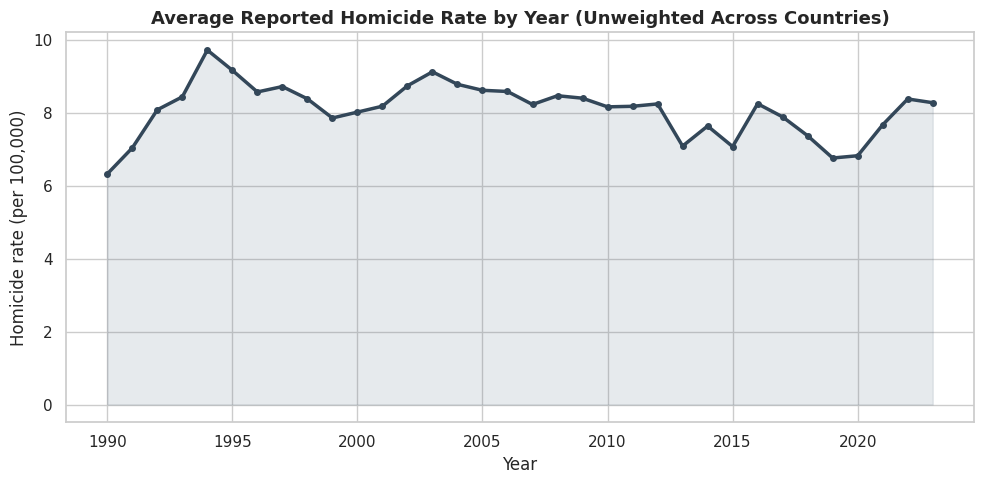

In [6]:
global_trend = agg.groupby('year')['homicide_rate'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_trend.index, global_trend.values, color=SLATE, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(global_trend.index, global_trend.values, color=STEEL, alpha=0.15)
ax.set_title('Average Reported Homicide Rate by Year (Unweighted Across Countries)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Homicide rate (per 100,000)')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
This line is a simple average across whichever countries happen to have data in each year &mdash; it is <i>not</i> a population-weighted global rate, and given the uneven coverage found above, the set of countries contributing to each year's average isn't constant. Read it as a rough, unweighted indicator of the reporting countries' trend rather than a precise world figure. With that caveat, the actual shape is not a simple decline: the average <b>rises</b> from 6.3 in 1990 to a peak of <b>9.7 in 1994</b>, falls back to roughly 8 by 2000, and then holds in a <b>volatile band between about 7 and 9</b> for the following two decades with no clear sustained trend in either direction &mdash; 2022's value (8.4) is close to where the series stood in the early 2000s, not meaningfully lower.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">The Male/Female Disparity</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">One of the most consistent patterns in global homicide data: compare rates by sex directly, using properly matched country-year pairs.</p>
</div>


In [7]:
male_data = df[(df['sex'] == 'male') & (df['age_group'] == 'ALL')][['iso_code', 'year', 'homicide_rate']].rename(columns={'homicide_rate': 'male_rate'})
female_data = df[(df['sex'] == 'female') & (df['age_group'] == 'ALL')][['iso_code', 'year', 'homicide_rate']].rename(columns={'homicide_rate': 'female_rate'})
matched = male_data.merge(female_data, on=['iso_code', 'year'])
matched['ratio'] = matched['male_rate'] / matched['female_rate'].replace(0, np.nan)

print(f"Matched country-year pairs: {len(matched)}")
print(f"Median male rate: {matched['male_rate'].median():.2f}")
print(f"Median female rate: {matched['female_rate'].median():.2f}")
print(f"Median male:female ratio: {matched['ratio'].median():.2f}")

Matched country-year pairs: 2780
Median male rate: 3.88
Median female rate: 1.30
Median male:female ratio: 3.15


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Across <b>2,780</b> matched country-year pairs, the median male rate (<b>3.88</b> per 100,000) runs <b>3.15&times;</b> the median female rate (<b>1.30</b>) &mdash; consistent with a well-established pattern in global public health data: men are disproportionately both victims and perpetrators of homicide nearly everywhere. This isn't a quirk of this particular dataset; it shows up reliably across WHO and UNODC mortality statistics generally.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Visualizing the Gap</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The male/female rate gap as paired boxplots, on a log scale given the wide underlying range.</p>
</div>


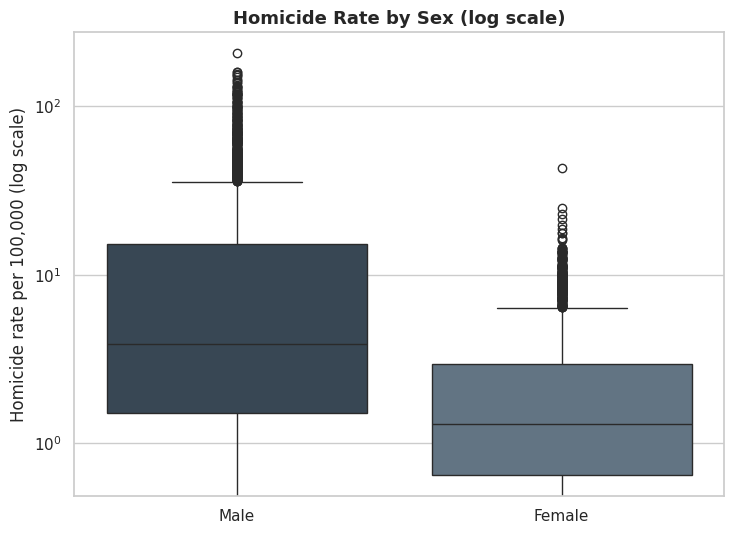

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
plot_data = pd.melt(matched[['male_rate', 'female_rate']], var_name='sex', value_name='rate')
plot_data['sex'] = plot_data['sex'].map({'male_rate': 'Male', 'female_rate': 'Female'})
sns.boxplot(data=plot_data, x='sex', y='rate', hue='sex', palette={'Male': SLATE, 'Female': STEEL},
            legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Homicide Rate by Sex (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Homicide rate per 100,000 (log scale)')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The gap holds up visually across the whole distribution, not just at the median shown above &mdash; the male box sits consistently higher than the female box at every quartile, even on a log scale that compresses the visual size of large differences.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Age Pattern, by Sex</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Given the structural finding in Section 03, age-group patterns have to be examined separately for each sex. Compare both curves directly.</p>
</div>


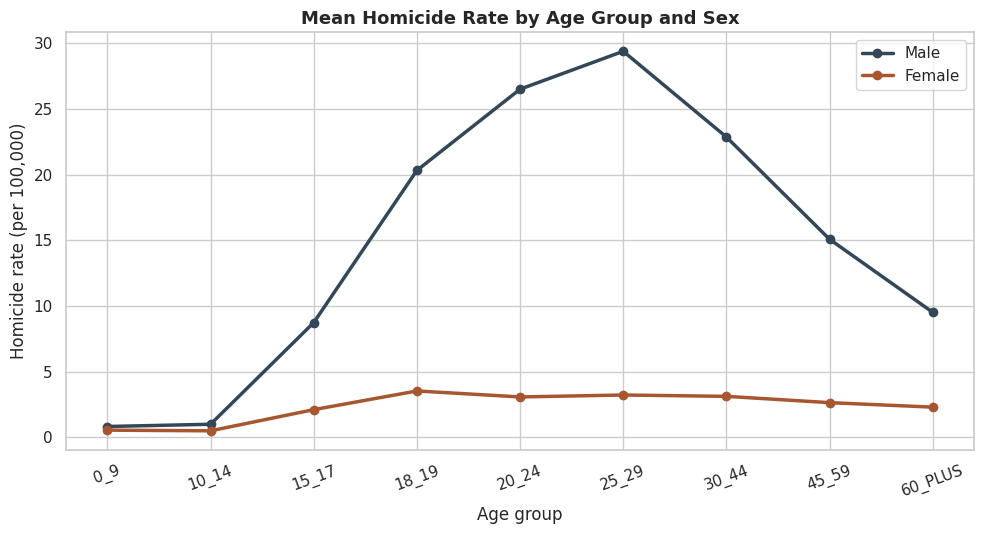

In [9]:
age_order = ['0_9', '10_14', '15_17', '18_19', '20_24', '25_29', '30_44', '45_59', '60_PLUS']

male_age = df[(df['sex'] == 'male') & (df['age_group'] != 'ALL')].groupby('age_group')['homicide_rate'].mean().reindex(age_order)
female_age = df[(df['sex'] == 'female') & (df['age_group'] != 'ALL')].groupby('age_group')['homicide_rate'].mean().reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(age_order, male_age.values, color=SLATE, linewidth=2.5, marker='o', label='Male')
ax.plot(age_order, female_age.values, color=RUST, linewidth=2.5, marker='o', label='Female')
ax.set_title('Mean Homicide Rate by Age Group and Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Age group')
ax.set_ylabel('Homicide rate (per 100,000)')
ax.legend()
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The male curve tells a sharp, specific story: rates climb steeply from childhood, <b>peak at ages 25-29 (29.4 per 100,000)</b> &mdash; over 35&times; the 0-9 rate &mdash; and then decline steadily through middle and older age. The female curve is far flatter by comparison, rising much more gently and peaking at a fraction of the male peak (<b>3.5</b> at ages 18-19). Both the size of the male/female gap and its concentration in young adulthood match well-documented patterns in criminological research on lethal violence.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Regional Comparison</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Group all 201 countries into continents for a manageable geographic comparison.</p>
</div>


In [10]:
!pip install pycountry-convert
import pycountry_convert as pc

def get_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        return pc.convert_continent_code_to_continent_name(pc.country_alpha2_to_continent_code(iso2))
    except Exception:
        return None

# a handful of entities pycountry_convert doesn't resolve automatically; mapped by hand
manual_map = {'CHA': 'Europe', 'VAT': 'Europe', 'XKX': 'Europe', 'TLS': 'Asia', 'EAW': 'Europe'}

df['continent'] = df['iso_code'].apply(get_continent)
df['continent'] = df['continent'].fillna(df['iso_code'].map(manual_map))
print(f"Unmapped rows remaining: {df['continent'].isna().sum()}")

agg_continent = df[(df['sex'] == 'both') & (df['age_group'] == 'ALL')]
regional = agg_continent.groupby('continent')['homicide_rate'].agg(['mean', 'median', 'count']).round(2).sort_values('mean', ascending=False)
regional

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 41.3 MB/s eta 0:00:00
Unmapped rows remaining: 0


,mean,median,count
continent,,,
South America,18.38,13.00,311
North America,18.32,12.64,940
Africa,8.56,4.71,456
Oceania,3.33,1.89,210
Asia,3.10,2.20,1034
Europe,2.70,1.34,1264


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
South America and North America show by far the highest mean rates (18.4 and 18.3 per 100,000), well above Africa (8.6), Oceania (3.3), Asia (3.1), and Europe (2.7). One precision worth stating clearly: <code>pycountry_convert</code>'s "North America" grouping spans the whole region from Canada down through Central America and the Caribbean. The countries actually driving that high mean are El Salvador, Honduras, Jamaica, and several Caribbean island nations &mdash; the United States sits well below the bucket's own average (a mean of 6.2 across these years) and Canada lower still. Reporting "North America has a high homicide rate" without that context would be misleading about which specific countries the pattern reflects.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Country-Level Extremes</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Identify the specific highest values in the dataset, and check whether they reflect real, known events rather than data artifacts.</p>
</div>


In [11]:
top10 = agg.nlargest(10, 'homicide_rate')[['country', 'year', 'homicide_rate']]
top10

,country,year,homicide_rate
6837,El Salvador,1995,138.438378
6836,El Salvador,1994,134.281183
6838,El Salvador,1996,116.996820
6839,El Salvador,1997,112.463210
6924,El Salvador,2015,107.638231
6840,El Salvador,1998,94.953374
4423,Colombia,1991,85.877334
6933,El Salvador,2016,85.085802
4426,Colombia,1992,83.481999
9297,Honduras,2011,83.179333


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The ten highest values are dominated by <b>El Salvador</b> (appearing 5 times, including the single highest value of <b>138.4</b> in 1995) alongside Colombia and Honduras. These aren't data errors: they correspond to well-documented historical periods &mdash; El Salvador in the years immediately following its 1980-1992 civil war, and a second, separate gang-violence peak around 2015; Colombia during the early-1990s height of cartel-related violence; Honduras during an early-2010s surge in gang activity. Extreme values in this kind of data are frequently real historical signal, not noise to be filtered out.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">El Salvador in Detail</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The dataset's most extreme country deserves a closer look at its full trajectory, not just its peak value.</p>
</div>


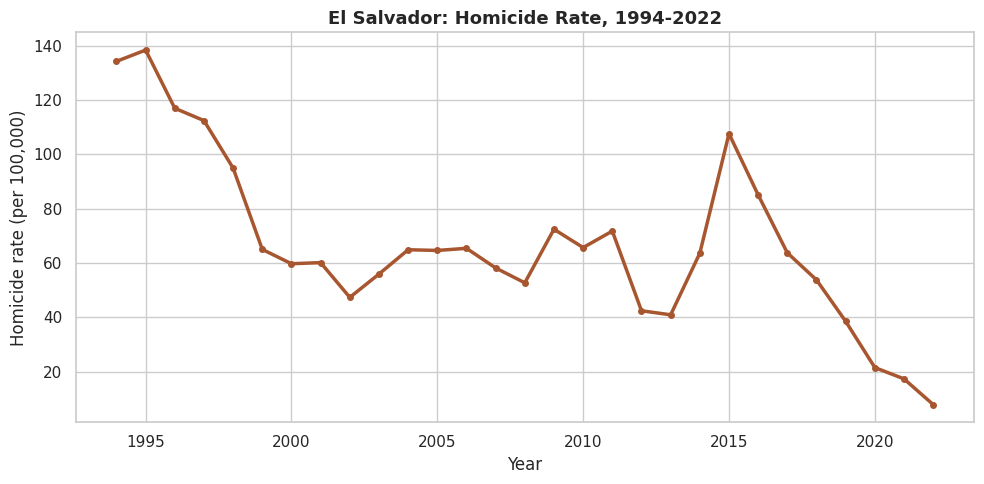

In [12]:
slv = df[(df['country'] == 'El Salvador') & (df['sex'] == 'both') & (df['age_group'] == 'ALL')].sort_values('year')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slv['year'], slv['homicide_rate'], color=RUST, linewidth=2.5, marker='o', markersize=4)
ax.set_title('El Salvador: Homicide Rate, 1994-2022', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Homicide rate (per 100,000)')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The trajectory is more complex than a single "steady decline" &mdash; and it would be an oversimplification to call it that. There's a real post-civil-war decline from 1995 to 2002, then a volatile, roughly-flat plateau through the 2000s and early 2010s, punctuated by a sharp secondary spike to <b>107.6</b> in 2015 during a renewed gang war. Only from around 2019 onward does the rate fall sharply and consistently, down to <b>7.9</b> by 2022 &mdash; a period that coincides with El Salvador's well-documented state-of-emergency gang crackdown policies. A single average or a single trend line across the full period would flatten a genuinely eventful history into a misleadingly smooth story.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 50%, #5d7488 82%, #8fa2b0 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Which Countries Changed the Most</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Fit a simple linear trend per country (restricted to countries with at least 15 years of data) to find the steepest improvers and decliners.</p>
</div>


In [13]:
from scipy import stats

trends = []
for country, grp in agg.groupby('country'):
    if len(grp) >= 15:
        grp = grp.sort_values('year')
        slope, intercept, r, p, se = stats.linregress(grp['year'], grp['homicide_rate'])
        trends.append({'country': country, 'n_years': len(grp), 'slope_per_year': slope, 'mean_rate': grp['homicide_rate'].mean()})

trends_df = pd.DataFrame(trends)
print(f"Countries with at least 15 years of data: {len(trends_df)}")
print()
print("Steepest declines (most improved):")
print(trends_df.sort_values('slope_per_year').head(6)[['country', 'n_years', 'slope_per_year', 'mean_rate']].round(3))
print()
print("Steepest increases (most worsened):")
print(trends_df.sort_values('slope_per_year', ascending=False).head(6)[['country', 'n_years', 'slope_per_year', 'mean_rate']].round(3))

Countries with at least 15 years of data: 137

Steepest declines (most improved):
          country  n_years  slope_per_year  mean_rate
39    El Salvador       29          -2.572     67.025
28       Colombia       34          -1.993     47.664
113  South Africa       29          -0.807     40.379
95       Paraguay       24          -0.770     13.352
102        Russia       32          -0.698     18.518
40        Estonia       30          -0.452      7.647

Steepest increases (most worsened):
                          country  n_years  slope_per_year  mean_rate
132  United States Virgin Islands       16           1.897     35.814
104         Saint Kitts and Nevis       26           1.307     31.496
127      Turks and Caicos Islands       24           1.278     12.189
53                          Haiti       15           1.185     11.658
124           Trinidad and Tobago       23           0.917     27.800
135                     Venezuela       31           0.857     34.522


<div style="
    border-left: 4px solid #a8562f;
    background: #f4efe9;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #211c17;
">
<b style="color:#a8562f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
El Salvador and Colombia show the steepest declining trends of any country with sufficient data (roughly &minus;2.6 and &minus;2.0 per 100,000 per year respectively) &mdash; both starting from very high rates, so a linear slope here captures large net improvement even though (as Section 12 showed for El Salvador specifically) the real path was far from a straight line. On the other side, several Caribbean island nations and Venezuela show clear worsening trends. This linear-trend approach is a genuine simplification &mdash; it summarizes overall direction, not the shape of the journey &mdash; but restricting it to countries with at least 15 years of data keeps the comparison from being driven by countries with only a handful of scattered points.
</div>


<div style="
    background: linear-gradient(100deg, #1c2733 0%, #334759 55%, #5d7488 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>This is panel data with a specific nesting structure</b>: sex='both' rows only ever pair with age_group='ALL', so age-pattern analysis has to be done separately within male and female, not on the combined-sex rows.</li>
<li><b>Data availability is itself uneven and non-random</b>: only about 62% of the theoretical country-year maximum is present, and the thinnest coverage clusters in fragile or low-capacity states &mdash; a real limitation, not just a formality to mention once.</li>
<li><b>The male/female gap is large and consistent</b>: a median 3.15&times; ratio across 2,780 matched country-year pairs, concentrated most sharply in young adulthood (male rates peak at ages 25-29, over 35&times; the childhood rate).</li>
<li><b>Regional patterns need precise attribution</b>: the high "North America" mean is driven by Central American and Caribbean nations, not the United States or Canada specifically &mdash; a distinction that matters for not misreading the finding.</li>
<li><b>Extreme values here are real historical signal</b>: El Salvador, Colombia, and Honduras's highest recorded rates correspond to documented civil-war aftermath and gang-violence periods, not data errors &mdash; and El Salvador's own trajectory shows a volatile, multi-phase history rather than a simple steady decline.</li>
<li>This dataset aggregates what are themselves estimates from national reporting systems of varying quality and completeness; treat specific rate values, especially for countries with sparse coverage, as estimates rather than precise counts.</li>
</ul>
</div>
